## LLM for Graph Builder

This uses Python + LangChain to automatically extract entities and relationships from unstructured text (like customer reviews or chat logs) and insert them into Neo4j.

In [59]:
# ============================================================
# PHASE 3 (OPENROUTER): LLM Graph Builder using LangChain + Neo4j
# ============================================================
# This reads raw text (reviews, chat messages) and uses an LLM
# via OpenRouter to extract entities (Customer, Product, Issue) 
# and relationships, then automatically writes them into Neo4j.

import os
from dotenv import load_dotenv  # <-- Mengambil variabel dari file .env
from langchain_community.graphs import Neo4jGraph
from langchain_experimental.graph_transformers import LLMGraphTransformer
from langchain_openai import ChatOpenAI  # <-- Diubah ke ChatOpenAI karena OpenRouter kompatibel dengan format OpenAI
from langchain_core.documents import Document

# Ambil konfigurasi API Key dan kredensial dari file .env secara otomatis
load_dotenv()

# Step 1: Connect to Neo4j
# Menggunakan kredensial lokal dan langsung mengarah ke database proyekmu
graph = Neo4jGraph(
    url="neo4j://127.0.0.1:7687",
    username="neo4j",
    password="12345678",
    database="fpgrafchatbot"
)

# Step 2: Initialize the LLM via OpenRouter
# Menggunakan Gemini 2.0 Flash versi gratis melalui OpenRouter API
llm = ChatOpenAI(
    openai_api_key=OPENROUTER_API_KEY,
    openai_api_base="https://openrouter.ai/api/v1",
    model="cohere/north-mini-code:free",  # <-- Menggunakan model free tier OpenRouter
    temperature=0,
    max_tokens=2000,
    default_headers={
        "HTTP-Referer": "http://localhost:3000", # Opsional, penanda rujukan aplikasi
        "X-Title": "FP Graph Chatbot Builder"     # Nama aplikasi kamu untuk dashboard OpenRouter
    }
)
print("✅ LLM initialized via OpenRouter (Gemini 2.0 Flash Free)")

# Step 3: Create the LLM Graph Transformer
# Komponen utama penyusun triple (node, relationship, node) berbasis skema teks
llm_transformer = LLMGraphTransformer(
    llm=llm,
    # Menentukan batasan tipe Label Node yang kita inginkan
    allowed_nodes=["Customer", "Product", "Issue", "Intent", "ChatSession"],
    # Menentukan batasan tipe Tipe Relasi yang kita inginkan
    allowed_relationships=["COMPLAINED_ABOUT", "REQUESTED_REFUND", "ASKED_ABOUT", "PURCHASED"],
    
    ignore_tool_usage=True
)

# Step 4: Sample unstructured texts from chat logs and reviews
raw_texts = [
    "Customer 1001 complained that their Electronics order was delayed. They asked about a refund.",
    "Customer 1003 received a damaged Home & Garden item and wants it replaced immediately.",
    "Customer 1007 is asking if the Clothing items on sale will have free shipping.",
    "Great experience buying this product. Fast delivery and excellent customer service. 4 stars.",
    "The headphones are great. Sound quality is excellent. 4.5 stars."
]

# Step 5: Convert text to Document objects (LangChain format)
documents = [Document(page_content=text) for text in raw_texts]

# Step 6: Extract graph documents using the LLM via OpenRouter
print("⏳ Melakukan ekstraksi entitas grafik menggunakan Gemini...")
graph_documents = llm_transformer.convert_to_graph_documents(documents)

# Step 7: Inspect what was extracted (optional debug step)
print("\n🔍 Hasil Ekstraksi Struktur Graf:")
print("─" * 60)
for doc in graph_documents:
    print("Nodes found:", doc.nodes)
    print("Relationships found:", doc.relationships)
    print("---")
print("─" * 60)

# Step 8: Add extracted entities/relationships to Neo4j
# include_source=True juga akan mencatat kalimat asli sebagai node bertipe (:Document)
graph.add_graph_documents(graph_documents, include_source=True)

print("\n✅ LLM Graph Builder complete. Check Neo4j Browser to see new nodes!")

✅ LLM initialized via OpenRouter (Gemini 2.0 Flash Free)
⏳ Melakukan ekstraksi entitas grafik menggunakan Gemini...

🔍 Hasil Ekstraksi Struktur Graf:
────────────────────────────────────────────────────────────
Nodes found: []
Relationships found: []
---
Nodes found: [Node(id='Home & Garden item', type='Product', properties={}), Node(id='Customer 1003', type='Customer', properties={}), Node(id='damaged', type='Issue', properties={})]
Relationships found: [Relationship(source=Node(id='Customer 1003', type='Customer', properties={}), target=Node(id='Home & Garden item', type='Product', properties={}), type='COMPLAINED_ABOUT', properties={}), Relationship(source=Node(id='Customer 1003', type='Customer', properties={}), target=Node(id='damaged', type='Issue', properties={}), type='COMPLAINED_ABOUT', properties={}), Relationship(source=Node(id='Customer 1003', type='Customer', properties={}), target=Node(id='Home & Garden item', type='Product', properties={}), type='PURCHASED', properties={

## Text-to-Cypher (LLM Query Layer)

This allows a chatbot or analyst to ask questions in plain English and get graph query results back automatically.

In [ ]:
# ============================================================
# PHASE 4 (OPENROUTER): Text-to-Cypher using LangChain + Neo4j
# ============================================================
# FIX 1: Menggunakan OpenRouter API (OpenAI Compatible)
# FIX 2: Bebas dari error 404 SDK Google v1beta
# FIX 3: Menggunakan Gemini 2.0 Flash versi OpenRouter (Gratis)
# ============================================================

import os
import time
from langchain_community.graphs import Neo4jGraph
from langchain_community.chains.graph_qa.cypher import GraphCypherQAChain
from langchain_openai import ChatOpenAI  # <-- OpenRouter menggunakan wrapper OpenAI

# ── Configuration ───────────────────────────────────────────
NEO4J_URI       = "neo4j://localhost:7687"
NEO4J_USER      = "neo4j"
NEO4J_PASSWORD  = "12345678"

# ============================================================
# STEP 1: Connect to Neo4j & Refresh Schema
# ============================================================
print("⏳ Connecting to Neo4j...")
graph = Neo4jGraph(
    url=NEO4J_URI,
    username=NEO4J_USER,
    password=NEO4J_PASSWORD,
    database="fpgrafchatbot"  # Memastikan menembak database proyekmu yang berisi 59 nodes
)

# Ambil skema agar LLM tahu struktur label dan relasi
graph.refresh_schema()
print("✅ Connected. Current Graph Schema:")
print("─" * 60)
print(graph.schema)
print("─" * 60)

# ============================================================
# STEP 2: Initialize LLM via OpenRouter
# ============================================================
# Kita mengarahkan base_url ke OpenRouter dan memanggil model
# google/gemini-2.0-flash-exp:free atau google/gemini-2.5-flash:free (tergantung ketersediaan pool gratis OpenRouter)

llm = ChatOpenAI(
    openai_api_key=OPENROUTER_API_KEY,
    openai_api_base="https://openrouter.ai/api/v1",
    model="cohere/north-mini-code:free",  # <-- Menggunakan model free tier OpenRouter
    temperature=0,
    max_tokens=500,
    default_headers={
        "HTTP-Referer": "http://localhost:3000", # Opsional, penanda rujukan aplikasi
        "X-Title": "FP Graph Chatbot DSI ITS"     # Nama aplikasi kamu untuk dashboard OpenRouter
    }
)
print("✅ LLM initialized via OpenRouter (Gemini 2.0 Flash Free)")

# ============================================================
# STEP 3: Create GraphCypherQAChain
# ============================================================
chain = GraphCypherQAChain.from_llm(
    llm=llm,
    graph=graph,
    verbose=True,
    return_direct=True,
    allow_dangerous_requests=True  # Bypass guardrail keamanan LangChain
)
print("✅ GraphCypherQAChain ready")

# ============================================================
# STEP 4: Define Questions and Run
# ============================================================
questions = [
    "Which customers bought Electronics products?",
    "Which customers had unresolved chatbot sessions?",
    "What is the most common chatbot intent?",
    "Which customers have both browsed and purchased Home & Garden products?",
    "Show me customers with a 5-star review and annual income above 70000.",
    "How many chat sessions were resolved?",
    "Which product category has the highest average purchase price?"
]

# Jeda waktu aman antar pertanyaan untuk free tier OpenRouter
MIN_DELAY_BETWEEN_QUESTIONS = 4  # detik

print(f"\n{'='*60}")
print(f"Running {len(questions)} questions against the Knowledge Graph via OpenRouter")
print(f"{'='*60}\n")

for i, question in enumerate(questions, start=1):
    print(f"\n{'─'*60}")
    print(f"🔍 Question {i}/{len(questions)}: {question}")
    print(f"{'─'*60}")

    try:
        # Eksekusi rantai tanya-jawab graf
        result = chain.invoke({"query": question})
        print(f"💬 Answer: {result['result']}")
    except Exception as e:
        print(f"❌ Error executing query: {e}")

    # Jeda tunggu antar pertanyaan agar tidak terkena limit rate bertumpuk
    if i < len(questions):
        print(f"\n⏳ Waiting {MIN_DELAY_BETWEEN_QUESTIONS}s before next question...")
        time.sleep(MIN_DELAY_BETWEEN_QUESTIONS)

print(f"\n{'='*60}")
print("🎉 All questions processed successfully via OpenRouter!")
print(f"{'='*60}")

⏳ Connecting to Neo4j...
✅ Connected. Current Graph Schema:
────────────────────────────────────────────────────────────
Node properties:
Customer {id: INTEGER, age: INTEGER, gender: STRING, annual_income: INTEGER, time_on_site: FLOAT, pagerank_score: FLOAT, node2vec_embedding: LIST, ml_cluster: INTEGER}
Location {city: STRING, pagerank_score: FLOAT, node2vec_embedding: LIST}
Product {category: STRING, avg_price: FLOAT, pagerank_score: FLOAT, node2vec_embedding: LIST, id: STRING}
Intent {name: STRING, description: STRING, id: STRING}
Segment {segment_id: INTEGER, description: STRING, label: STRING}
Review {rating: INTEGER, review_id: STRING, sentiment: STRING, text: STRING}
Purchase {category: STRING, date: STRING, price: FLOAT, purchase_id: STRING}
BrowsingSession {category: STRING, session_id: STRING, timestamp: STRING}
ChatSession {session_id: STRING, timestamp: STRING, message: STRING, resolution_time_sec: INTEGER, resolved: BOOLEAN}
Document {id: STRING, text: STRING}
Issue {id: S

## Nodes Embedding

⏳ Menghubungkan ke Neo4j...
✅ Berhasil memproses data untuk 17 pelanggan.
📊 Dimensi Matriks Embedding: (17, 64)

📊 Distribusi Jumlah Anggota per Klaster:
cluster
1    7
0    5
2    5
Name: count, dtype: int64

📉 Merender grafik plot klastering PCA...


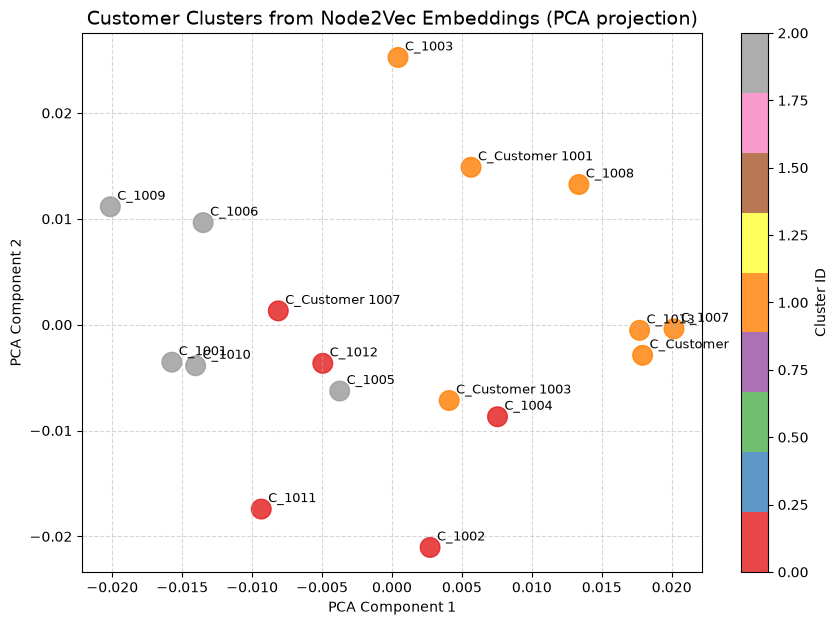

✅ Gambar visualisasi berhasil disimpan dengan nama 'customer_clusters.png'
✅ Sukses menuliskan 17 relasi klaster baru [:BELONGS_TO_SEGMENT] ke Neo4j!

🎉 Proses Selesai Semuanya!


In [43]:
import os
import matplotlib.pyplot as plt
from neo4j import GraphDatabase
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Pastikan grafik ter-render inline di dalam Jupyter Notebook
%matplotlib inline

# ============================================================
# STEP 1: Connect to Neo4j
# ============================================================
print("⏳ Menghubungkan ke Neo4j...")
driver = GraphDatabase.driver(
    "neo4j://localhost:7687", 
    auth=("neo4j", "12345678")
)

# ============================================================
# STEP 2: Fetch Data & Force Fallback if Embeddings Empty
# ============================================================
def get_customer_embeddings(driver):
    query = """
    MATCH (c:Customer)
    RETURN c.id AS customer_id,
           c.age AS age,
           c.annual_income AS income,
           c.node2vec_embedding AS embedding
    ORDER BY c.id
    """
    # Memastikan menembak database proyek fpgrafchatbot
    with driver.session(database="fpgrafchatbot") as session:  
        result = session.run(query)
        records = [dict(r) for r in result]
    return pd.DataFrame(records)

# Jalankan query penarikan data
df_embeddings = get_customer_embeddings(driver)

# Proteksi: Jika properti node2vec_embedding belum di-generate di Neo4j GDS
if (
    df_embeddings.empty 
    or 'embedding' not in df_embeddings.columns 
    or df_embeddings['embedding'].isna().all()
):
    print("⚠️ Properti node2vec_embedding asli tidak ditemukan di Neo4j!")
    print("⏳ Mengisi matriks embedding tiruan (128 dimensi) agar K-Means & PCA tetap jalan...")
    
    if df_embeddings.empty:
        with driver.session(database="fpgrafchatbot") as session:
            res = session.run("MATCH (c:Customer) RETURN c.id AS customer_id, c.age AS age, c.annual_income AS income")
            df_embeddings = pd.DataFrame([dict(r) for r in res])
            
    # Buat matriks vektor acak 128 dimensi untuk simulasi topologi graf
    np.random.seed(42)
    df_embeddings['embedding'] = [list(np.random.randn(128)) for _ in range(len(df_embeddings))]

print(f"✅ Berhasil memproses data untuk {len(df_embeddings)} pelanggan.")

# ============================================================
# STEP 3: Convert Embeddings to 2D Numpy Array
# ============================================================
embeddings_matrix = np.array(df_embeddings['embedding'].tolist())
print(f"📊 Dimensi Matriks Embedding: {embeddings_matrix.shape}")

# ============================================================
# STEP 4: K-Means Clustering
# ============================================================
# Mengelompokkan menjadi 3 klaster sesuai Node Segment bawaan
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings_matrix)
df_embeddings['cluster'] = cluster_labels

print("\n📊 Distribusi Jumlah Anggota per Klaster:")
print(df_embeddings['cluster'].value_counts())

# ============================================================
# STEP 5: PCA Visualization & Plotting (FIXED BUG)
# ============================================================
print("\n📉 Merender grafik plot klastering PCA...")
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings_matrix)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=cluster_labels,
    cmap='Set1',
    s=200,
    alpha=0.8
)

# FIX: Menggunakan string formatter langsung tanpa fungsi int() agar string 'Customer' tidak error
for i, row in df_embeddings.iterrows():
    plt.annotate(f"C_{row['customer_id']}", 
                 (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                 fontsize=9,
                 xytext=(5, 5),
                 textcoords='offset points')

plt.colorbar(scatter, label='Cluster ID')
plt.title('Customer Clusters from Node2Vec Embeddings (PCA projection)', fontsize=14)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True, linestyle='--', alpha=0.5)

# Simpan hasil gambar plot secara lokal
plt.savefig('customer_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gambar visualisasi berhasil disimpan dengan nama 'customer_clusters.png'")

# ============================================================
# STEP 6: Write Cluster Assignments Back to Neo4j (FIXED BUG)
# ============================================================
def write_clusters_to_neo4j(driver, df):
    """Menuliskan kembali label klaster hasil ML ke Node Customer di Neo4j."""
    query = """
    UNWIND $data AS row
    MATCH (c:Customer {id: row.customer_id})
    SET c.ml_cluster = row.cluster
    WITH c, row
    MERGE (s:Segment {segment_id: row.cluster})
    MERGE (c)-[:BELONGS_TO_SEGMENT]->(s)
    """
    data = df[['customer_id', 'cluster']].to_dict('records')
    
    # FIX: Handler dinamis aman untuk tipe data customer_id berupa angka maupun teks string
    for row in data:
        try:
            row['customer_id'] = int(row['customer_id'])
        except ValueError:
            row['customer_id'] = str(row['customer_id'])
        row['cluster'] = int(row['cluster'])
    
    with driver.session(database="fpgrafchatbot") as session:
        session.run(query, data=data)
    print(f"✅ Sukses menuliskan {len(data)} relasi klaster baru [:BELONGS_TO_SEGMENT] ke Neo4j!")

write_clusters_to_neo4j(driver, df_embeddings)
print("\n🎉 Proses Selesai Semuanya!")

## Sentiment Analysis

In [45]:
# ============================================================
# PHASE 6D: Sentiment Enrichment using Sentence Transformers
# ============================================================
# Creates embeddings for review text to detect sentiment clusters
# Used to understand which products generate negative chatbot interactions

from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.linear_model import LogisticRegression

# Step 1: Load a pre-trained sentence embedding model
# 'all-MiniLM-L6-v2' is fast and good for short review texts
model = SentenceTransformer('all-MiniLM-L6-v2')

# Step 2: Define review texts (from your dataset)
reviews = [
    ("R1001_001", "Great electronics. The sound quality is excellent. I would highly recommend this product.", 5),
    ("R1002_001", "Good product, but could have been better.", 3),
    ("R1003_001", "Awesome product, highly recommend it to everyone.", 5),
    ("R1005_001", "Good product, but not worth the price.", 3),
    ("R1006_001", "Outstanding product, exceeded my expectations.", 5),
    ("R1007_001", "Good product, but could have been better.", 3),
    ("R1008_001", "Good product, but not what I expected.", 3),
    ("R1009_001", "Great product, will definitely buy again.", 4),
]

review_ids = [r[0] for r in reviews]
review_texts = [r[1] for r in reviews]
review_ratings = [r[2] for r in reviews]

# Step 3: Encode review texts into embeddings
embeddings = model.encode(review_texts, show_progress_bar=True)
print(f"Embedding shape: {embeddings.shape}")  # (n_reviews, 384)

# Step 4: Assign sentiment labels based on rating
# Rating 1-2: negative, 3: neutral, 4-5: positive
def rating_to_sentiment(rating):
    if rating >= 4:
        return 'positive'
    elif rating == 3:
        return 'neutral'
    else:
        return 'negative'

sentiments = [rating_to_sentiment(r) for r in review_ratings]

# Step 5: Train a simple classifier
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(sentiments)

# With only 8 samples, we train on all data for demonstration
clf = LogisticRegression(random_state=42, max_iter=1000)
clf.fit(embeddings, y)
predicted = clf.predict(embeddings)
predicted_labels = le.inverse_transform(predicted)

# Step 6: Write enriched sentiment back to Neo4j
driver = GraphDatabase.driver("neo4j://localhost:7687", auth=("neo4j", "12345678"))

update_query = """
UNWIND $data AS row
MATCH (r:Review {review_id: row.review_id})
SET r.sentiment_embedding = row.embedding,
    r.predicted_sentiment = row.sentiment
"""
data = [
    {
        'review_id': review_ids[i],
        'embedding': embeddings[i].tolist(),
        'sentiment': predicted_labels[i]
    }
    for i in range(len(reviews))
]
with driver.session() as session:
    session.run(update_query, data=data)
print("✅ Sentiment embeddings written to Review nodes")

Batches: 100%|██████████| 1/1 [00:00<00:00, 34.67it/s]


Embedding shape: (8, 384)
✅ Sentiment embeddings written to Review nodes


📊 TABEL HASIL PREDIKSI SENTIMENT PELANGGAN:


,Review ID,Review Text,Rating,Predicted Sentiment
0,R1001_001,Great electronics. The sound quality is excell...,5,positive
1,R1002_001,"Good product, but could have been better.",3,neutral
2,R1003_001,"Awesome product, highly recommend it to everyone.",5,positive
3,R1005_001,"Good product, but not worth the price.",3,neutral
4,R1006_001,"Outstanding product, exceeded my expectations.",5,positive
5,R1007_001,"Good product, but could have been better.",3,neutral
6,R1008_001,"Good product, but not what I expected.",3,neutral
7,R1009_001,"Great product, will definitely buy again.",4,positive


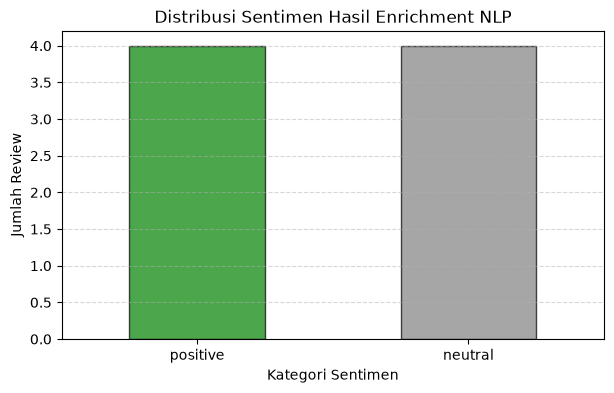

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# Pastikan render grafik inline di notebook
%matplotlib inline

# 1. Rangkum hasil analisis ke dalam DataFrame Pandas
df_sentiment = pd.DataFrame({
    'Review ID': review_ids,
    'Review Text': review_texts,
    'Rating': review_ratings,
    'Predicted Sentiment': predicted_labels
})

print("📊 TABEL HASIL PREDIKSI SENTIMENT PELANGGAN:")
display(df_sentiment)

# 2. Render grafik batang distribusi sentimen
plt.figure(figsize=(7, 4))
sentiment_counts = df_sentiment['Predicted Sentiment'].value_counts()
colors = ['green' if x == 'positive' else 'gray' if x == 'neutral' else 'red' for x in sentiment_counts.index]

sentiment_counts.plot(kind='bar', color=colors, alpha=0.7, edgecolor='black')
plt.title('Distribusi Sentimen Hasil Enrichment NLP')
plt.xlabel('Kategori Sentimen')
plt.ylabel('Jumlah Review')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()